# Recurrent Neural Networks, from the Problem They Solve

*A from-scratch derivation, built around the experiment that put RNNs on the map.*

This notebook does four things, in order:

1. **Exposes the core problem.** We pick a deliberately tiny task that a feedforward network provably *cannot* solve, and watch it fail in a way whose accuracy we can predict to the decimal.
2. **Derives the fix.** We introduce recurrence as the minimal architectural change that gives a network *memory*, and write out the forward pass by hand.
3. **Derives learning.** We derive **Backpropagation Through Time (BPTT)** from scratch, implement it in NumPy, and confirm it against numerical gradients.
4. **Reproduces the seminal result.** We rebuild the letter-prediction experiment from Elman's *"Finding Structure in Time"* (1990) and watch a network discover word boundaries in an unbroken stream of characters — with no supervision about where words begin.

### The papers this is built on
- **J. L. Elman (1990), "Finding Structure in Time,"** *Cognitive Science* 14(2), 179–211 — the simple recurrent network (the "Elman network"), and the experiment we reproduce in Part 6.
- **M. I. Jordan (1986), "Serial Order,"** UCSD ICS Report — the other early recurrent architecture (output-to-state feedback).
- **Rumelhart, Hinton & Williams (1986), "Learning representations by back-propagating errors,"** *Nature* 323 — the backprop machinery we extend through time.
- **Werbos (1990), "Backpropagation Through Time"** — BPTT named and formalized.
- **Bengio, Simard & Frasconi (1994)** and **Hochreiter & Schmidhuber (1997)** — why the vanilla recurrence struggles on long ranges, and the LSTM that fixes it (Part 7).

> Everything in Parts 1–5 is pure NumPy so nothing is hidden behind a framework. PyTorch shows up only for the baseline and for the final Elman experiment.

In [1]:
import numpy as np
import torch, torch.nn as nn
import matplotlib.pyplot as plt

np.random.seed(0); torch.manual_seed(0)
plt.rcParams.update({'figure.figsize': (8, 4), 'axes.grid': True,
                     'grid.alpha': 0.3, 'font.size': 11})
def sigmoid(z): return 1.0 / (1.0 + np.exp(-z))

## Part 1 — The core problem: feedforward nets have no memory

A feedforward network computes a fixed function of a **fixed-size** input: $\hat y = f(x)$. Three things break the moment the data is a *sequence* $x_1, x_2, \dots, x_T$:

1. **No notion of unbounded history.** $f$ takes one input. To feed it a sequence you must flatten a *fixed window* into one vector — so anything outside the window is invisible, forever.
2. **No weight sharing across time.** A flattened MLP learns a separate weight for "the bit 3 steps ago" vs "the bit 4 steps ago." The rule it needs is usually the *same* at every step.
3. **No state.** Nothing carries information from step $t$ to step $t{+}1$.

To make this concrete and *measurable*, we need a task where the answer at step $t$ depends on the **entire** history $x_1,\dots,x_t$, not just a recent slice.

### The task: running parity
Given a stream of bits $x_1,\dots,x_T \in \{0,1\}$, output at each step the parity (XOR) of everything seen so far:
$$ y_t \;=\; x_1 \oplus x_2 \oplus \cdots \oplus x_t \;=\; \Big(\textstyle\sum_{i\le t} x_i\Big) \bmod 2. $$

Parity is the canonical "needs memory" task: it has the clean recurrence $y_t = y_{t-1} \oplus x_t$, so it requires **exactly one bit of state** — flip the answer iff the current bit is 1. A network with memory needs to track one bit; a network without memory is helpless, and we can prove it.

In [2]:
def make_parity(n_seqs, T, seed=0):
    rng = np.random.default_rng(seed)
    X = rng.integers(0, 2, size=(n_seqs, T))
    Y = np.cumsum(X, axis=1) % 2
    return X.astype(np.float64), Y.astype(np.float64)

X, Y = make_parity(2000, 20, seed=0)
xt, yt = X.reshape(-1), Y.reshape(-1)
print("A memoryless model sees only the current bit x_t. Is x_t informative about y_t?\n")
print(f"  P(y_t = 1)            = {yt.mean():.3f}")
print(f"  P(y_t = 1 | x_t = 0)  = {yt[xt==0].mean():.3f}")
print(f"  P(y_t = 1 | x_t = 1)  = {yt[xt==1].mean():.3f}")
print("\nThe current bit carries essentially NO information about the running parity:")
print("conditioning on x_t leaves the target a coin flip. Any function of x_t alone is stuck at chance.")

A memoryless model sees only the current bit x_t. Is x_t informative about y_t?

  P(y_t = 1)            = 0.501
  P(y_t = 1 | x_t = 0)  = 0.479
  P(y_t = 1 | x_t = 1)  = 0.524

The current bit carries essentially NO information about the running parity:
conditioning on x_t leaves the target a coin flip. Any function of x_t alone is stuck at chance.


So a per-timestep model is hopeless. The natural feedforward rescue is a **sliding window**: feed the MLP the last $w$ bits. Does that work? Let's sweep the window size and find out — and let's *predict* the result before we run it.

A window of size $w$ contains bits $x_{t-w+1},\dots,x_t$. Running parity factorizes as
$$ y_t = \underbrace{\text{parity}(x_1,\dots,x_{t-w})}_{\text{outside the window — a fair coin}} \;\oplus\; \underbrace{\text{parity}(x_{t-w+1},\dots,x_t)}_{\text{inside the window}}. $$
The first term is an independent random bit the window can't see, so for any step $t>w$ the window tells you **nothing**. The *only* steps a window-$w$ model can get right are the early ones, $t \le w$, where the window (left-padded with zeros) happens to span the whole history. That predicts a train accuracy of
$$ \text{acc}(w) \;\approx\; \frac{w}{T}\cdot 1 + \frac{T-w}{T}\cdot \tfrac{1}{2} \;=\; \tfrac{1}{2} + \tfrac{1}{2}\,\frac{w}{T}. $$
Let's check that an actual trained MLP obeys this.

  window w= 1:  MLP train acc = 0.523   (predicted 0.525)
  window w= 2:  MLP train acc = 0.548   (predicted 0.550)
  window w= 3:  MLP train acc = 0.574   (predicted 0.575)
  window w= 5:  MLP train acc = 0.625   (predicted 0.625)
  window w= 8:  MLP train acc = 0.702   (predicted 0.700)
  window w=12:  MLP train acc = 0.817   (predicted 0.800)
  window w=20:  MLP train acc = 0.978   (predicted 1.000)


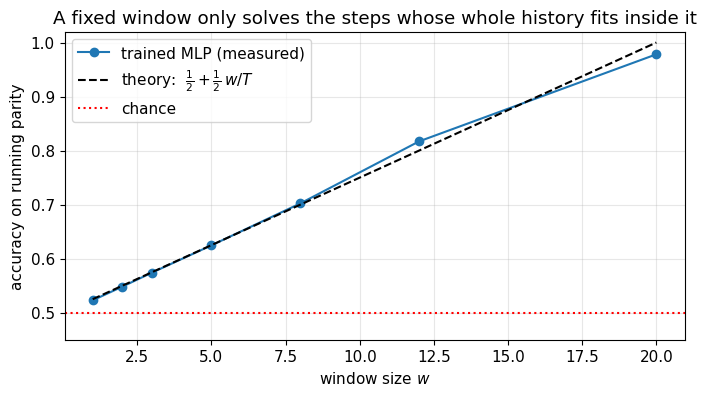

In [3]:
def windowed(X, w):
    N, T = X.shape
    Xp = np.concatenate([np.zeros((N, w-1)), X], axis=1)
    return np.stack([Xp[:, i:i+w] for i in range(T)], axis=1)  # (N, T, w)

def train_windowed_mlp(w, epochs=400):
    torch.manual_seed(0)
    feats = torch.tensor(windowed(X, w).reshape(-1, w), dtype=torch.float32)
    targ  = torch.tensor(Y.reshape(-1, 1), dtype=torch.float32)
    net = nn.Sequential(nn.Linear(w, 64), nn.ReLU(),
                        nn.Linear(64, 64), nn.ReLU(), nn.Linear(64, 1))
    opt = torch.optim.Adam(net.parameters(), lr=1e-2); lf = nn.BCEWithLogitsLoss()
    for _ in range(epochs):
        opt.zero_grad(); loss = lf(net(feats), targ); loss.backward(); opt.step()
    return ((torch.sigmoid(net(feats)) > 0.5).float() == targ).float().mean().item()

T = X.shape[1]
ws  = [1, 2, 3, 5, 8, 12, 20]
acc = [train_windowed_mlp(w) for w in ws]
pred = [0.5 + 0.5*w/T for w in ws]
for w, a, p in zip(ws, acc, pred):
    print(f"  window w={w:2d}:  MLP train acc = {a:.3f}   (predicted {p:.3f})")

plt.figure()
plt.plot(ws, acc, 'o-', label='trained MLP (measured)')
plt.plot(ws, pred, 'k--', label=r'theory:  $\frac{1}{2} + \frac{1}{2}\,w/T$')
plt.axhline(0.5, color='r', ls=':', label='chance')
plt.xlabel('window size $w$'); plt.ylabel('accuracy on running parity')
plt.title('A fixed window only solves the steps whose whole history fits inside it')
plt.legend(); plt.ylim(0.45, 1.02); plt.show()

The trained MLP tracks the theoretical line almost exactly. The lesson is sharp: **to get every step right, the window must be as large as the entire sequence** ($w \ge T$), and for sequences of unbounded length that means unbounded input — which a fixed feedforward net does not have.

What we want instead is a *fixed-size* model that nonetheless summarizes an *unbounded* past. That summary is called **state**, and the architecture that maintains it is the recurrent neural network.

## Part 2 — The recurrent idea

Elman's move (1990) is the minimal one. Keep an MLP, but give it a **hidden state** $h_t$ that is fed back in at the next step. At each time step the network reads the current input *and* its own previous state:

$$ \boxed{\,h_t = \tanh\!\big(W_{xh}\,x_t + W_{hh}\,h_{t-1} + b_h\big)\,}, \qquad \hat y_t = g\big(W_{hy}\,h_t + b_y\big), \qquad h_0 = \mathbf{0}. $$

Three properties fall straight out, and they are exactly the three failures from Part 1:

| Feedforward failure | Recurrent fix |
|---|---|
| no unbounded history | $h_t$ is a learned, fixed-size summary of *all* of $x_1{:}t$ |
| no weight sharing across time | the **same** $W_{xh}, W_{hh}, b_h$ are applied at every step |
| no state | $h_{t-1}\!\to\!h_t$ *is* the state channel |

Elman called $h_t$ the **context layer**; Jordan's earlier variant fed back the *output* $\hat y_{t-1}$ instead of the hidden state. Feeding back the hidden state is what makes $h_t$ a free, learnable memory rather than being tied to the prediction.

To train it, we **unroll** the recurrence in time into a (very deep, weight-tied) feedforward graph: $h_1$ depends on $h_0,x_1$; $h_2$ on $h_1,x_2$; and so on. Once unrolled, it's just backprop — but the shared weights mean a single weight receives gradient from *every* time step. That's BPTT (Part 4).

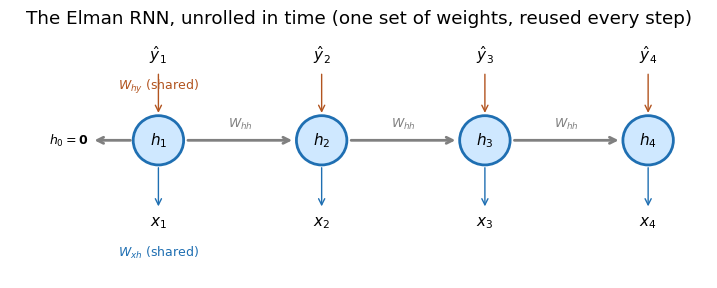

In [4]:
# A schematic of the unrolled Elman network: same weights reused at every step.
fig, ax = plt.subplots(figsize=(9, 3.2)); ax.axis('off')
xs = [0, 2.2, 4.4, 6.6]; labels = ['t=1', 't=2', 't=3', 't=4']
for i, x in enumerate(xs):
    ax.add_patch(plt.Circle((x, 1.0), 0.34, fc='#cfe8ff', ec='#1f6fb2', lw=2, zorder=3))
    ax.text(x, 1.0, r'$h_{%d}$' % (i+1), ha='center', va='center', zorder=4)
    ax.annotate('', (x, 0.66), (x, 0.05), arrowprops=dict(arrowstyle='<-', color='#1f6fb2'))
    ax.text(x, -0.18, r'$x_{%d}$' % (i+1), ha='center')
    ax.annotate('', (x, 1.95), (x, 1.34), arrowprops=dict(arrowstyle='<-', color='#b2541f'))
    ax.text(x, 2.1, r'$\hat y_{%d}$' % (i+1), ha='center')
    if i < len(xs)-1:
        ax.annotate('', (xs[i+1]-0.36, 1.0), (x+0.36, 1.0),
                    arrowprops=dict(arrowstyle='->', color='gray', lw=2))
        ax.text((x+xs[i+1])/2, 1.18, r'$W_{hh}$', ha='center', color='gray', fontsize=9)
ax.annotate('', (-0.9, 1.0), (-0.34, 1.0), arrowprops=dict(arrowstyle='->', color='gray', lw=2))
ax.text(-0.95, 1.0, r'$h_0=\mathbf{0}$', ha='right', va='center', fontsize=9)
ax.text(0, -0.6, r'$W_{xh}$ (shared)', ha='center', color='#1f6fb2', fontsize=9)
ax.text(0, 1.7, r'$W_{hy}$ (shared)', ha='center', color='#b2541f', fontsize=9)
ax.set_xlim(-2, 7.4); ax.set_ylim(-0.9, 2.5)
ax.set_title('The Elman RNN, unrolled in time (one set of weights, reused every step)')
plt.show()

## Part 3 — The forward pass, from scratch

We'll model running parity directly. Input dimension $D=1$ (one bit per step), hidden size $H$, and a single sigmoid output per step (probability that parity is 1). Stacking a minibatch of $N$ sequences, with $X \in \mathbb{R}^{N\times T\times D}$:

$$ h_t = \tanh\!\big(x_t W_{xh}^\top + h_{t-1} W_{hh}^\top + b_h\big), \qquad \ell_t = h_t W_{hy}^\top + b_y, \qquad \hat p_t = \sigma(\ell_t). $$

We cache every $h_t$ on the forward pass — BPTT needs them all.

In [5]:
def init_params(D=1, H=16, seed=0):
    rng = np.random.default_rng(seed); s = 1.0/np.sqrt(H)
    return dict(Wxh=rng.uniform(-s, s, (H, D)), Whh=rng.uniform(-s, s, (H, H)),
                bh=np.zeros(H), Why=rng.uniform(-s, s, (1, H)), by=np.zeros(1))

def rnn_forward(P, X):
    N, T, D = X.shape; H = P['bh'].shape[0]
    h = np.zeros((N, H)); hs = [h.copy()]; logits = np.zeros((N, T))
    for t in range(T):
        h = np.tanh(X[:, t, :] @ P['Wxh'].T + h @ P['Whh'].T + P['bh'])
        hs.append(h.copy())
        logits[:, t] = (h @ P['Why'].T + P['by'])[:, 0]
    return logits, hs            # hs has length T+1 (includes h_0)

P = init_params(D=1, H=16, seed=0)
Xb, Yb = make_parity(4, 8, seed=7)
logits, hs = rnn_forward(P, Xb[:, :, None])
print("input X (4 sequences of 8 bits):\n", Xb.astype(int))
print("\nlogits shape:", logits.shape, " | cached states:", len(hs), "(h_0 ... h_T)")
print("untrained P(parity=1) for seq 0:", np.round(sigmoid(logits[0]), 2))

input X (4 sequences of 8 bits):
 [[1 1 1 1 1 1 1 0]
 [0 0 0 1 1 0 0 1]
 [0 1 0 0 1 0 0 0]
 [1 0 1 0 0 1 1 1]]

logits shape: (4, 8)  | cached states: 9 (h_0 ... h_T)
untrained P(parity=1) for seq 0: [0.49 0.49 0.49 0.49 0.49 0.49 0.49 0.49]


## Part 4 — Learning: deriving Backpropagation Through Time

Per-step binary cross-entropy, averaged over the batch and time:
$$ \mathcal L = \frac{1}{NT}\sum_{n}\sum_{t} \Big[-y_t\log\hat p_t-(1-y_t)\log(1-\hat p_t)\Big]. $$

**Output layer.** The sigmoid+BCE gradient collapses to the familiar residual:
$$ \frac{\partial \mathcal L}{\partial \ell_t} = \frac{1}{NT}\,(\hat p_t - y_t) \;\equiv\; \delta\ell_t, \qquad \frac{\partial \mathcal L}{\partial W_{hy}} = \sum_t \delta\ell_t\, h_t^\top, \qquad \frac{\partial \mathcal L}{\partial b_y} = \sum_t \delta\ell_t. $$

**The recurrent core — where "through time" comes in.** The state $h_t$ influences the loss through **two** paths: directly via the output $\hat y_t$, and indirectly because it feeds $h_{t+1}$ (which feeds $h_{t+2}$, …). So its gradient is a sum over both, giving a backward recursion that runs from $t=T$ down to $1$:
$$ \underbrace{\delta h_t}_{\partial \mathcal L/\partial h_t} \;=\; \underbrace{\delta\ell_t\, W_{hy}}_{\text{from output at }t} \;+\; \underbrace{\delta a_{t+1}\, W_{hh}}_{\text{from the future, }h_{t+1}}. $$

Push $\delta h_t$ back through the $\tanh$ (whose derivative is $1-h_t^2$) to get the pre-activation gradient $\delta a_t = (1-h_t^2)\odot \delta h_t$. The three recurrent parameter gradients then **accumulate across all time steps**, because the weights are shared:
$$ \frac{\partial \mathcal L}{\partial W_{xh}} = \sum_t \delta a_t^\top x_t, \qquad \frac{\partial \mathcal L}{\partial W_{hh}} = \sum_t \delta a_t^\top h_{t-1}, \qquad \frac{\partial \mathcal L}{\partial b_h} = \sum_t \delta a_t. $$

**The key object for later.** Unrolling $\delta h_t$ shows the gradient from step $t$ to step $t-k$ carries the product
$$ \prod_{j=t-k+1}^{t} \frac{\partial h_j}{\partial h_{j-1}} = \prod_j \operatorname{diag}(1-h_j^2)\,W_{hh}^\top. $$
A product of $k$ Jacobians: its norm tends to **shrink or blow up geometrically** in $k$. Hold that thought — it is exactly why long-range learning is hard (Part 7).

In [6]:
def rnn_loss_and_grad(P, X, Y):
    N, T, D = X.shape; H = P['bh'].shape[0]
    logits, hs = rnn_forward(P, X); p = sigmoid(logits)
    loss = -np.mean(Y*np.log(p+1e-12) + (1-Y)*np.log(1-p+1e-12))
    g = {k: np.zeros_like(v) for k, v in P.items()}
    dh_next = np.zeros((N, H))                      # gradient flowing back from h_{t+1}
    for t in reversed(range(T)):
        dlogit = (p[:, t] - Y[:, t]) / (N*T)        # delta_ell_t   (N,)
        g['Why'] += dlogit[None, :] @ hs[t+1]       # sum_t dlogit * h_t^T
        g['by']  += dlogit.sum(keepdims=True)
        dh  = dlogit[:, None] @ P['Why'] + dh_next  # delta h_t  (output path + future path)
        da  = (1 - hs[t+1]**2) * dh                 # through tanh -> delta a_t
        g['Wxh'] += da.T @ X[:, t, :]
        g['Whh'] += da.T @ hs[t]                    # note: h_{t-1} = hs[t]
        g['bh']  += da.sum(axis=0)
        dh_next   = da @ P['Whh']                   # propagate to h_{t-1}
    return loss, g, p

### Sanity check: analytic BPTT vs. numerical gradients
A derivation is only as trustworthy as its gradient check. We perturb each parameter by $\pm\epsilon$ and compare the central difference $\frac{\mathcal L(\theta+\epsilon)-\mathcal L(\theta-\epsilon)}{2\epsilon}$ to the analytic gradient. Relative errors near $10^{-9}$ mean the BPTT above is correct.

In [7]:
Xc, Yc = make_parity(8, 6, seed=1); Xc = Xc[:, :, None]
Pc = init_params(D=1, H=5, seed=2)
_, g, _ = rnn_loss_and_grad(Pc, Xc, Yc); eps = 1e-5
print("max relative error (analytic BPTT vs central difference):")
for k in Pc:
    A = Pc[k]; ng = np.zeros_like(A); it = np.nditer(A, flags=['multi_index'])
    while not it.finished:
        i = it.multi_index; o = A[i]
        A[i] = o + eps; lp, _, _ = rnn_loss_and_grad(Pc, Xc, Yc)
        A[i] = o - eps; lm, _, _ = rnn_loss_and_grad(Pc, Xc, Yc)
        A[i] = o; ng[i] = (lp - lm) / (2*eps); it.iternext()
    rel = np.abs(ng - g[k]).max() / (np.abs(ng).max() + 1e-12)
    print(f"  {k:4s}: {rel:.2e}")

max relative error (analytic BPTT vs central difference):
  Wxh : 3.36e-10
  Whh : 4.25e-09
  bh  : 4.52e-10
  Why : 3.24e-10
  by  : 2.53e-10


## Part 5 — Training the RNN on the task the MLP couldn't do

Same loss, plain Adam, hidden size 16. We train on length-20 sequences and then — the real test of *memory* — evaluate on sequences **twice as long** (length 40). A windowed MLP's accuracy is capped by its window; a working RNN should generalize, because it learned a *rule over state*, not a lookup over positions.

Training the from-scratch RNN on running parity:


  step  200   loss 0.4687   train acc 0.696


  step  400   loss 0.5020   train acc 0.711


  step  600   loss 0.0049   train acc 1.000


  step  800   loss 0.0021   train acc 1.000


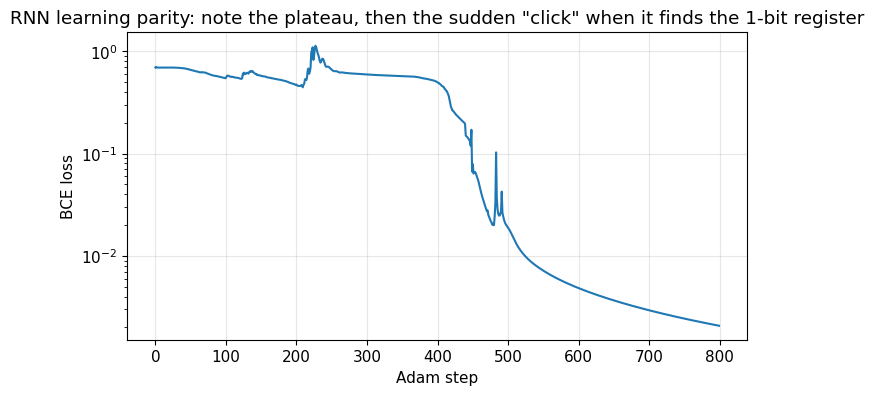

In [8]:
def adam_train(steps=800, lr=5e-2, H=16, Ttrain=20, n=1024, seed=3, log_every=200):
    Xtr, Ytr = make_parity(n, Ttrain, seed=0); Xtr = Xtr[:, :, None]
    P = init_params(D=1, H=H, seed=seed)
    m = {k: np.zeros_like(v) for k, v in P.items()}
    v = {k: np.zeros_like(x) for k, x in P.items()}
    b1, b2, e = 0.9, 0.999, 1e-8; hist = []
    for s in range(1, steps+1):
        loss, g, _ = rnn_loss_and_grad(P, Xtr, Ytr); hist.append(loss)
        for k in P:
            m[k] = b1*m[k] + (1-b1)*g[k]; v[k] = b2*v[k] + (1-b2)*g[k]**2
            P[k] -= lr * (m[k]/(1-b1**s)) / (np.sqrt(v[k]/(1-b2**s)) + e)
        if s % log_every == 0:
            acc = ((sigmoid(rnn_forward(P, Xtr)[0]) > 0.5) == Ytr).mean()
            print(f"  step {s:4d}   loss {loss:.4f}   train acc {acc:.3f}")
    return P, hist

print("Training the from-scratch RNN on running parity:")
P_parity, hist = adam_train()

plt.figure(); plt.plot(hist)
plt.xlabel('Adam step'); plt.ylabel('BCE loss')
plt.title('RNN learning parity: note the plateau, then the sudden "click" when it finds the 1-bit register')
plt.yscale('log'); plt.show()

In [9]:
# The decisive comparison: generalize to LONGER sequences than seen in training.
print("Trained only on length-20 sequences. Now test on unseen lengths:\n")
print(f"{'length':>8} | {'RNN acc':>8} | {'best window-MLP (w=20) acc':>26}")
print("-"*52)
for L in [20, 30, 40, 60]:
    Xt, Yt = make_parity(512, L, seed=100+L)
    rnn_acc = ((sigmoid(rnn_forward(P_parity, Xt[:, :, None])[0]) > 0.5) == Yt).mean()
    mlp_acc = 0.5 + 0.5*min(20, L)/L          # theoretical ceiling of a w=20 MLP
    print(f"{L:>8} | {rnn_acc:>8.3f} | {mlp_acc:>26.3f}")
print("\nThe RNN holds ~100% as sequences grow; the windowed MLP's ceiling decays as 1/L.")

Trained only on length-20 sequences. Now test on unseen lengths:

  length |  RNN acc | best window-MLP (w=20) acc
----------------------------------------------------
      20 |    1.000 |                      1.000
      30 |    1.000 |                      0.833


      40 |    1.000 |                      0.750
      60 |    1.000 |                      0.667

The RNN holds ~100% as sequences grow; the windowed MLP's ceiling decays as 1/L.


### What did it learn? Peeking inside the state
Parity needs *one bit* of memory. If the RNN really solved the task, some direction in its hidden state should behave like a parity register — flipping every time a `1` arrives. We correlate each hidden unit's activation with the true running parity and plot the most parity-aligned unit along one sequence.

Most parity-aligned hidden unit: #12  (|correlation| = 0.54)


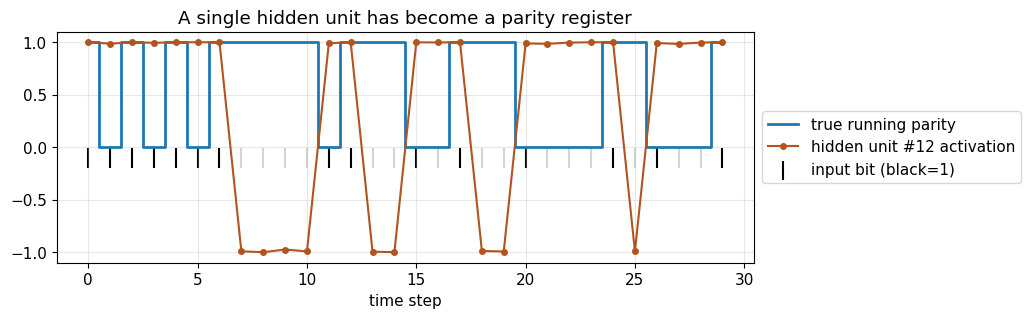

In [10]:
Xs, Ys = make_parity(256, 30, seed=7)
_, HS = rnn_forward(P_parity, Xs[:, :, None])
Hmat = np.stack(HS[1:], axis=1)                       # (N, T, H)
signed = 2*Ys - 1                                     # parity in {-1,+1}
corr = np.array([np.corrcoef(Hmat[:, :, j].ravel(), signed.ravel())[0, 1]
                 for j in range(Hmat.shape[2])])
best = int(np.nanargmax(np.abs(corr)))
print(f"Most parity-aligned hidden unit: #{best}  (|correlation| = {abs(corr[best]):.2f})")

seq = 0
fig, ax = plt.subplots(figsize=(9, 3))
ax.step(range(30), Ys[seq], where='mid', label='true running parity', lw=2)
ax.plot(range(30), Hmat[seq, :, best], 'o-', ms=4, color='#b2541f',
        label=f'hidden unit #{best} activation')
ax.scatter(range(30), Xs[seq]*0 - 0.1, c=['k' if b else 'lightgray' for b in Xs[seq]],
           marker='|', s=200, label='input bit (black=1)')
ax.set_xlabel('time step'); ax.set_title('A single hidden unit has become a parity register')
ax.legend(loc='center left', bbox_to_anchor=(1, 0.5)); plt.show()

## Part 6 — The seminal experiment: Elman's *"Finding Structure in Time"* (1990)

Parity proves an RNN *can* hold state. Elman's experiment shows why that matters for *language*: a recurrent net, trained only to predict the next item, **discovers structure nobody told it about**.

**The setup (faithful to the paper).** Take a tiny lexicon of words built from a consonant followed by a fixed run of vowels:

> `ba`,  `dii`,  `guuu`

Generate a long stream by concatenating randomly chosen words with **no spaces, no boundaries, no markers** — just an undifferentiated sequence of letters like `…guuudiibaba…`. Train an Elman RNN to predict the next letter, one character at a time.

**The prediction.** Within a word the next letter is *deterministic* once you've seen the consonant (`b`→`a`; `d`→`ii`; `g`→`uuu`), so a network with memory should predict vowels almost perfectly. But the *first* letter of each word — which word comes next — is genuinely random. So if the network has learned the structure, its prediction error should **spike exactly at word onsets and collapse inside words**. The error curve becomes a word-boundary detector the network was never trained to be.

In [11]:
words = ['ba', 'dii', 'guuu']
alphabet = sorted(set(''.join(words)))            # ['a','b','d','g','i','u']
stoi = {c: i for i, c in enumerate(alphabet)}; V = len(alphabet)

def make_stream(n_words, seed=0):
    rng = np.random.default_rng(seed)
    chosen = [words[i] for i in rng.integers(0, len(words), size=n_words)]
    s = ''.join(chosen)
    pos = [p for w in chosen for p in range(len(w))]   # within-word index of each char
    return s, np.array(pos)

stream, _ = make_stream(2000, seed=0)
print("alphabet:", alphabet)
print("a slice of the undifferentiated training stream:")
print(" ", stream[:48], "...")
print(f"stream length: {len(stream)} characters")

alphabet: ['a', 'b', 'd', 'g', 'i', 'u']
a slice of the undifferentiated training stream:
  guuudiidiibabababababaguuudiiguuudiidiiguuuguuud ...
stream length: 6061 characters


In [12]:
# Train a compact Elman RNN (PyTorch) to predict the next character.
idx = np.array([stoi[c] for c in stream])
Xoh = torch.nn.functional.one_hot(torch.tensor(idx[:-1]), V).float().unsqueeze(0)
Ytg = torch.tensor(idx[1:]).unsqueeze(0)

class CharRNN(nn.Module):
    def __init__(self, V, H=12):
        super().__init__()
        self.rnn = nn.RNN(V, H, batch_first=True, nonlinearity='tanh')  # Elman cell
        self.dec = nn.Linear(H, V)
    def forward(self, x, h=None):
        out, h = self.rnn(x, h); return self.dec(out), h

torch.manual_seed(0)
net = CharRNN(V, H=12)
opt = torch.optim.Adam(net.parameters(), lr=5e-3); lf = nn.CrossEntropyLoss()
for epoch in range(120):
    opt.zero_grad(); logits, _ = net(Xoh)
    loss = lf(logits.reshape(-1, V), Ytg.reshape(-1)); loss.backward(); opt.step()
    if (epoch+1) % 40 == 0:
        print(f"  epoch {epoch+1:3d}   cross-entropy {loss.item():.4f}")

  epoch  40   cross-entropy 1.1794


  epoch  80   cross-entropy 0.4983


  epoch 120   cross-entropy 0.4010


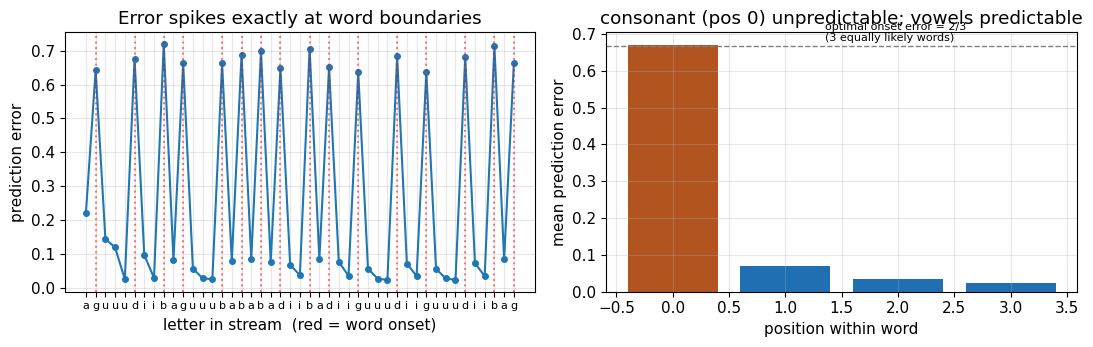

mean error by within-word position: [np.float32(0.671), np.float32(0.069), np.float32(0.034), np.float32(0.025)]


In [13]:
# Evaluate on a FRESH stream. Error = 1 - P(model assigns to the true next letter).
test_stream, pos = make_stream(400, seed=123)
tidx = np.array([stoi[c] for c in test_stream])
tX = torch.nn.functional.one_hot(torch.tensor(tidx[:-1]), V).float().unsqueeze(0)
tY = tidx[1:]
with torch.no_grad():
    tlog, _ = net(tX)
    prob = torch.softmax(tlog[0], dim=-1).numpy()
err = 1 - prob[np.arange(len(tY)), tY]
pos_t = pos[1:]                                   # within-word position of each predicted letter

fig, (a1, a2) = plt.subplots(1, 2, figsize=(11, 3.6))
# (left) the iconic Elman plot: error along the stream, boundaries marked
sl = slice(0, 45)
a1.plot(range(45), err[sl], 'o-', ms=4)
for i in range(45):
    if pos_t[sl][i] == 0:                          # word-initial letter
        a1.axvline(i, color='r', ls=':', alpha=0.5)
a1.set_xticks(range(45)); a1.set_xticklabels(list(test_stream[1:46]), fontsize=8)
a1.set_xlabel('letter in stream  (red = word onset)'); a1.set_ylabel('prediction error')
a1.set_title('Error spikes exactly at word boundaries')
# (right) average error by within-word position
maxp = pos_t.max()
means = [err[pos_t == k].mean() for k in range(maxp+1)]
a2.bar(range(maxp+1), means, color=['#b2541f']+['#1f6fb2']*maxp)
a2.set_xlabel('position within word'); a2.set_ylabel('mean prediction error')
a2.set_title('consonant (pos 0) unpredictable; vowels predictable')
a2.axhline(2/3, color='gray', ls='--', lw=1)
a2.text(maxp*0.45, 0.68, 'optimal onset error = 2/3\n(3 equally likely words)', fontsize=8)
plt.tight_layout(); plt.show()

print("mean error by within-word position:", [round(m, 3) for m in means])

Read the right panel: the word-initial consonant sits at error $\approx 2/3$ — which is **optimal**, because three words are equally likely so the best possible guess puts $1/3$ on the true onset. Every vowel position collapses to near zero. The left panel is Elman's famous figure: feed the trained network an unbroken letter stream and its error rises precisely at each new word and falls as the word unfolds.

Nobody told the network where words start. It inferred lexical structure purely from the statistics of prediction over time — *because it had a state in which to accumulate that structure.* That is the entire thesis of "Finding Structure in Time," and it is the reason recurrence became the default tool for language for the next quarter-century.

## Part 7 — The catch, and where this leads

Recall the gradient object from Part 4: signal crossing $k$ steps is multiplied by $\prod_j \operatorname{diag}(1-h_j^2)\,W_{hh}^\top$, a product of $k$ Jacobians. Its size is governed roughly by the spectral radius $\rho$ of $W_{hh}$ (the $\tanh$ derivative only shrinks things further, since $1-h^2 \le 1$):

- $\rho < 1 \Rightarrow$ gradients **vanish** geometrically — the network can't learn dependencies more than a handful of steps back.
- $\rho > 1 \Rightarrow$ gradients can **explode**.

Let's watch it happen: push a unit gradient backward through a random RNN and track its norm vs. distance.

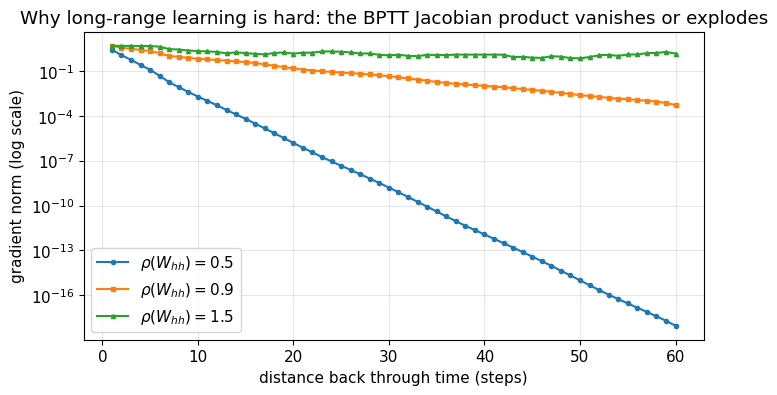

At rho=0.5 the gradient loses ~18 orders of magnitude over 60 steps: long-range signal is gone.


In [14]:
def grad_norm_vs_distance(rho, T=60, H=32, seed=0):
    rng = np.random.default_rng(seed)
    W = rng.standard_normal((H, H))
    W = W / np.max(np.abs(np.linalg.eigvals(W))) * rho     # set spectral radius
    h = np.tanh(rng.standard_normal(H)); hs = [h]
    for _ in range(T):
        h = np.tanh(W @ h + 0.1*rng.standard_normal(H)); hs.append(h)
    g = rng.standard_normal(H); norms = []
    for t in reversed(range(T)):
        g = W.T @ ((1 - hs[t+1]**2) * g); norms.append(np.linalg.norm(g))
    return np.array(norms[::-1])

plt.figure()
for rho, style in [(0.5, 'o-'), (0.9, 's-'), (1.5, '^-')]:
    n = grad_norm_vs_distance(rho)
    plt.semilogy(range(1, len(n)+1), n[::-1], style, ms=3, label=fr'$\rho(W_{{hh}})={rho}$')
plt.xlabel('distance back through time (steps)'); plt.ylabel('gradient norm (log scale)')
plt.title('Why long-range learning is hard: the BPTT Jacobian product vanishes or explodes')
plt.legend(); plt.show()
print("At rho=0.5 the gradient loses ~18 orders of magnitude over 60 steps: long-range signal is gone.")

This is precisely the obstacle **Bengio, Simard & Frasconi (1994)** formalized, and it's what **Hochreiter & Schmidhuber's LSTM (1997)** was designed to defeat: a gated cell with an additive memory path whose Jacobian stays near 1, so gradients neither vanish nor explode across long spans. **GRUs** (Cho et al., 2014) are a lighter variant of the same idea. Everything in this notebook — state, weight sharing, unrolling, BPTT — carries over unchanged to those models; they only swap the cell's internal update for one that protects the gradient.

### Recap
1. **The problem.** Sequence targets can depend on unbounded history; a fixed-window feedforward net is capped at accuracy $\tfrac{1}{2} + \tfrac{1}{2}\,w/T$ on parity — provably blind beyond its window.
2. **The fix.** Recurrence: a fixed-size state $h_t = \tanh(W_{xh}x_t + W_{hh}h_{t-1}+b_h)$ summarizes the whole past, with weights shared across time.
3. **The learning rule.** BPTT — ordinary backprop on the unrolled graph, with recurrent-weight gradients accumulated over every step. We derived it and verified it to $10^{-9}$.
4. **Why it matters.** Trained only to predict the next letter, an Elman RNN recovered word structure from an unsegmented stream — Elman (1990).
5. **The limit.** The same Jacobian product that gives memory also makes long-range gradients vanish — the doorway to LSTMs and GRUs.

**References.** Elman (1990) *Cognitive Science* 14:179–211 · Jordan (1986) UCSD ICS 8604 · Rumelhart, Hinton & Williams (1986) *Nature* 323:533–536 · Werbos (1990) *Proc. IEEE* 78:1550–1560 · Bengio, Simard & Frasconi (1994) *IEEE TNN* 5:157–166 · Hochreiter & Schmidhuber (1997) *Neural Computation* 9:1735–1780 · Cho et al. (2014) arXiv:1406.1078.